# Analyze Autoregressive Rollout Error

This notebook loads the results generated by `evaluate.py` to visualize the model's long-term stability and display summary performance metrics.

### 1. Setup and Imports

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plot import plot_rollout_error

### 2. Specify Error File Path and Analyze

**Action Required:** Change the `error_file_path` variable below to point to the specific `rollout_error.npz` file you want to analyze.

Overall R² Score: -0.1815

Per-Channel R² Scores:


,Channel,R_Squared
0,x,0.977811
1,y,0.991311
2,z,0.987949
3,vx,0.034642
4,vy,0.016714
5,vz,-0.149450
6,jx,-0.093841
7,jy,-0.127711
8,jz,-0.266459
9,P,0.316449


2025-07-06 17:32:24,497 - INFO - Loading rollout error from /raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/rollout_error_train_val.npz...
/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/packages/mhd_surrogate_core/src/mhd_surrogate_core/plot.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  error_path (Path | str): Path to the latent_space_analysis.npz file.


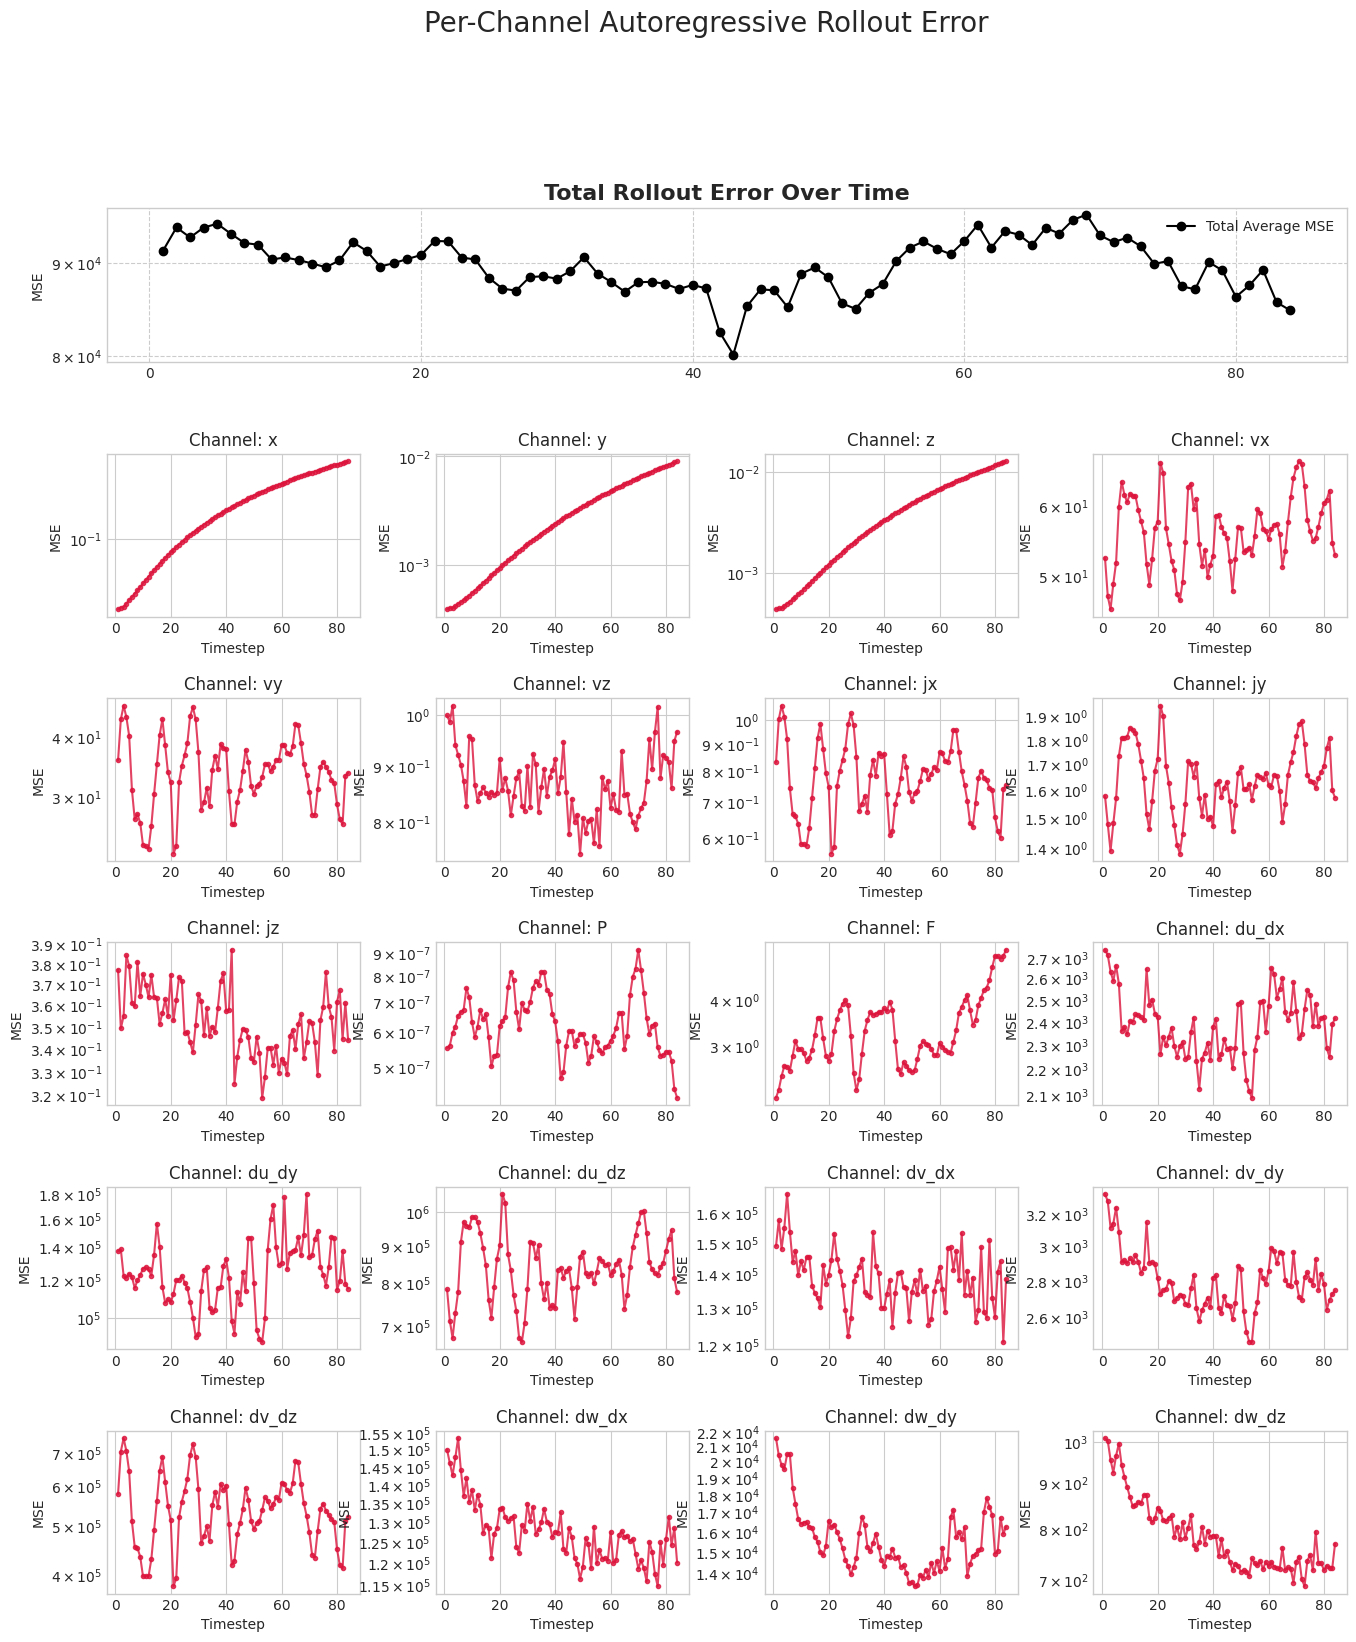

In [4]:
# Example path - update this to your specific run's output.
error_file_path = Path("/raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/rollout_error_train_val.npz")

if error_file_path.exists():
    # --- Load all metrics from the file ---
    with np.load(error_file_path, allow_pickle=True) as data:
        channel_names = data['channel_names']
        r_squared_total = data['r_squared_total']
        r_squared_per_channel = data['r_squared_per_channel']
    
    # --- Display Summary Table ---
    print(f"Overall R² Score: {r_squared_total:.4f}\n")
    
    df = pd.DataFrame({
        'Channel': channel_names,
        'R_Squared': r_squared_per_channel
    })
    print("Per-Channel R² Scores:")
    display(df)
    
    # --- Generate the Plot ---
    plot_rollout_error(error_file_path)
else:
    print(f"ERROR: Error file not found at {error_file_path}")